# 🚗 Modelo de Riesgo de Accidente de Tráfico — Medellín
## Probabilidad de Accidente por Hora, Barrio y Estacionalidad

---

### 🎯 Objetivo del Proyecto

Construir un modelo de machine learning que prediga la **probabilidad de que ocurra al menos un accidente**
de tráfico en una ubicación específica, un **día de la semana** y una **franja horaria** determinada,
**incorporando estacionalidad anual** (diferenciando invierno de verano, festividades, etc.).

### 🤔 ¿Por qué necesitamos estacionalidad (día del año)?

Un modelo que solo usa `DIA_SEMANA` (0=Lunes...6=Domingo) trata **todos los sábados como iguales**.
Pero la realidad no es así:

- Un **sábado 14 de febrero** (San Valentín) → más salidas nocturnas → más riesgo
- Un **sábado 25 de diciembre** (Navidad) → menos tráfico → menos riesgo
- Un **lunes 1 de enero** (Año Nuevo) → menos tráfico que un lunes normal

Para capturar estos efectos, usamos **seno y coseno del día del año**, que mapean el tiempo a un círculo.
Así el 1 de enero y el 31 de diciembre están cerca en el espacio numérico.

### 💾 Estrategia de memoria

Para no explotar la RAM, **NO agrupamos por día exacto** (lo que multiplicaría filas por 365).
En su lugar:
1. Agrupamos por `MES` (12 categorías)
2. Asignamos a cada mes el **día 15** como representante (ej: enero → día 15)
3. Calculamos `DIA_ANIO_SIN` y `DIA_ANIO_COS` sobre ese día representativo
4. El modelo aprende estacionalidad suave sin explotar la memoria

### 📦 Datos de entrada

- **Fuente:** Registros administrativos de incidentes de tráfico en Medellín, Colombia
- **Período:** 2008-01-01 a 2025-08-31
- **Volumen:** Aproximadamente 700,000 registros
- **Formato:** Archivo Excel (`Fatal_Road_Traffic.xlsx`)

### 🧩 Estrategia de modelado

El dataset original solo contiene registros donde **sí ocurrió un accidente** (eventos positivos).
Para entrenar un modelo de clasificación necesitamos también ejemplos de **no accidentes**.

**Enfoque ("El truco del target"):**
1. Crear una **grilla** con todas las combinaciones posibles de ubicación × día_semana × franja_horaria × mes
2. Las combinaciones que aparecen en el dataset original → etiqueta **1** (hubo accidente)
3. Las combinaciones que **no** aparecen → etiqueta **0** (no hubo accidente)
4. Entrenar modelos de clasificación para distinguir condiciones de riesgo

### 🗑️ Política de manejo de nulos

Eliminamos todos los registros con valores nulos en columnas críticas:
- Fecha del incidente
- Hora del incidente
- Ubicación (barrio o comuna)

---
## Paso 0: Configuración del entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import xgboost as xgb

warnings.filterwarnings('ignore')

# Configuración de estilo para gráficos profesionales
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Configuración de pandas para mejor visualización
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✅ Entorno configurado correctamente")
print(f"   Pandas {pd.__version__}")
print(f"   XGBoost: {xgb.__version__}")

✅ Entorno configurado correctamente
   Pandas 2.2.2
   XGBoost: 3.2.0


---
## Paso 1: Carga del dataset

Cargamos el archivo Excel optimizando tipos de datos para ahorrar memoria.

In [2]:
# Diccionario con tipos de datos optimizados
dtype_dict = {
    'LLAVE': 'int32',
    'AÑO': 'int16',
    'CLASE_INCIDENTE': 'category',
    'GRAVEDAD_INCIDENTE': 'category',
    'Codigo Comuna Planeacion': 'str',
    'Comuna Planeacion': 'category',
    'Codigo Barrio Planeacion': 'str',
    'Barrio Planeacion': 'str',
    'Latitud': 'float32',
    'Longitud': 'float32'
}

# Solo cargamos las columnas necesarias
columnas_necesarias = [
    'LLAVE', 'AÑO', 'FECHA_INCIDENTE', 'HORA_INCIDENTE',
    'CLASE_INCIDENTE', 'GRAVEDAD_INCIDENTE',
    'Codigo Comuna Planeacion', 'Comuna Planeacion',
    'Codigo Barrio Planeacion', 'Barrio Planeacion'
]

print("⏳ Cargando dataset (~700,000 registros)...")

df = pd.read_excel(
    '/content/data/Fatal_Road_Traffic_Normalizado.xlsx',
    sheet_name='BD',
    dtype=dtype_dict,
    usecols=columnas_necesarias
)

print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"📊 Memoria usada: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"📅 Período: {df['AÑO'].min()} - {df['AÑO'].max()}")

⏳ Cargando dataset (~700,000 registros)...
✅ Dataset cargado: 702,540 filas × 10 columnas
📊 Memoria usada: 156.3 MB
📅 Período: 2008 - 2025


In [3]:
# Mostrar primeras filas para entender la estructura
print("📋 Vista previa de los datos:")
df.head()

📋 Vista previa de los datos:


,LLAVE,AÑO,FECHA_INCIDENTE,HORA_INCIDENTE,CLASE_INCIDENTE,GRAVEDAD_INCIDENTE,Codigo Comuna Planeacion,Comuna Planeacion,Codigo Barrio Planeacion,Barrio Planeacion
0,92541,2010,2010-06-13,18:30:00,Atropello,HERIDO,6,Doce de Octubre,0609,0
1,105973,2010,2010-10-19,15:10:00,Volcamiento,HERIDO,13,San Javier,0,0
2,203150,2013,2013-01-06,15:00:00,Choque,HERIDO,6,Doce de Octubre,0609,0
3,231663,2013,2013-08-09,15:00:00,Otro,HERIDO,6,Doce de Octubre,0609,0
4,239968,2013,2013-10-09,19:30:00,Volcamiento,HERIDO,6,Doce de Octubre,609,0


---
## Paso 2: Diagnóstico de valores nulos

In [4]:
print("🔍 DIAGNÓSTICO DE VALORES NULOS")
print("=" * 70)

nulos_df = pd.DataFrame({
    'Columna': df.columns,
    'Nulos': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Nulos', ascending=False)

print(nulos_df.to_string(index=False))
print(f"\n📊 Total de registros antes de limpieza: {len(df):,}")

🔍 DIAGNÓSTICO DE VALORES NULOS
                 Columna  Nulos  Porcentaje
       Barrio Planeacion  11683      1.6600
Codigo Barrio Planeacion  11683      1.6600
                     AÑO      0      0.0000
                   LLAVE      0      0.0000
         FECHA_INCIDENTE      0      0.0000
          HORA_INCIDENTE      0      0.0000
      GRAVEDAD_INCIDENTE      0      0.0000
         CLASE_INCIDENTE      0      0.0000
       Comuna Planeacion      0      0.0000
Codigo Comuna Planeacion      0      0.0000

📊 Total de registros antes de limpieza: 702,540


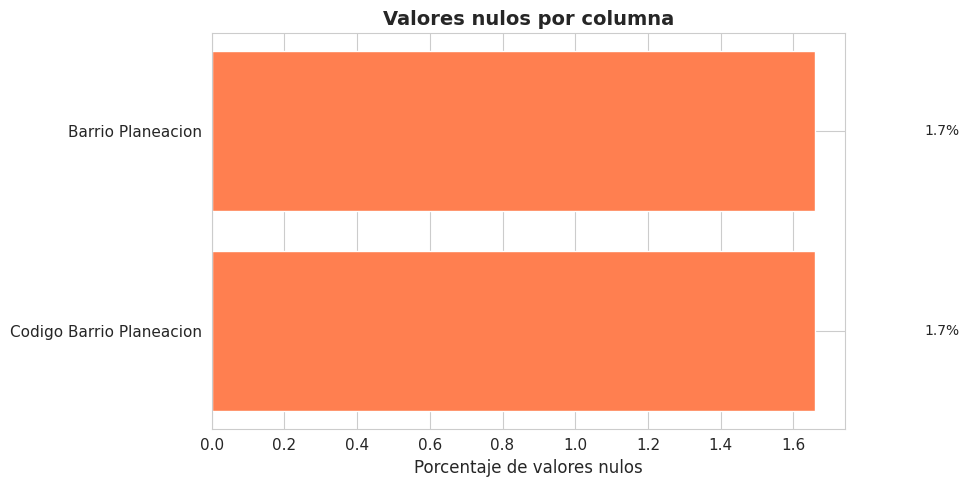

In [5]:
# Visualización de valores nulos
fig, ax = plt.subplots(figsize=(10, 5))

nulos_plot = nulos_df[nulos_df['Nulos'] > 0]
if len(nulos_plot) > 0:
    bars = ax.barh(nulos_plot['Columna'], nulos_plot['Porcentaje'], color='coral', edgecolor='white')
    ax.set_xlabel('Porcentaje de valores nulos', fontsize=12)
    ax.set_title('Valores nulos por columna', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    for bar, pct in zip(bars, nulos_plot['Porcentaje']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=10)
else:
    ax.text(0.5, 0.5, '✅ No hay valores nulos', ha='center', va='center', fontsize=14)
    ax.set_title('No hay valores nulos en el dataset', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Paso 3: Limpieza de datos

Eliminamos registros con valores nulos en columnas críticas.

**Columnas críticas:**
- `FECHA_INCIDENTE` — Sin fecha no podemos ubicar temporalmente
- `HORA_INCIDENTE` — Sin hora no podemos asignar franja
- `UBICACION` — Sin ubicación no hay análisis espacial

**Estrategia de ubicación:**
- Si el barrio es `"Sin inf"` o nulo → usamos la comuna
- Si ambos son inválidos → eliminamos el registro

In [6]:
registros_iniciales = len(df)

# ----- 3.1 Limpieza de fechas -----
print("📅 Procesando fechas...")
df['FECHA_INCIDENTE'] = pd.to_datetime(df['FECHA_INCIDENTE'], errors='coerce')
df = df.dropna(subset=['FECHA_INCIDENTE'])
perdidos_fecha = registros_iniciales - len(df)
print(f"   Eliminados por fecha inválida: {perdidos_fecha:,}")

# ----- 3.2 Limpieza de horas -----
print("⏰ Procesando horas...")
# Intentar formato HH:MM:SS
df['HORA_NUM'] = pd.to_datetime(df['HORA_INCIDENTE'], format='%H:%M:%S', errors='coerce').dt.hour
# Para los que fallaron, intentar HH:MM
mask_nan_hora = df['HORA_NUM'].isna()
df.loc[mask_nan_hora, 'HORA_NUM'] = pd.to_datetime(
    df.loc[mask_nan_hora, 'HORA_INCIDENTE'],
    format='%H:%M', errors='coerce'
).dt.hour

perdidos_hora = df['HORA_NUM'].isna().sum()
df = df.dropna(subset=['HORA_NUM'])
df['HORA_NUM'] = df['HORA_NUM'].astype('int8')
print(f"   Eliminados por hora inválida: {perdidos_hora:,}")

# ----- 3.3 Limpieza de ubicación -----
print("📍 Procesando ubicaciones...")
df['UBICACION_KEY'] = df['Barrio Planeacion'].copy()

# Donde barrio es inválido, usar comuna
mask_sin_barrio = (df['UBICACION_KEY'] == 'Sin inf') | (df['UBICACION_KEY'].isna())
df.loc[mask_sin_barrio, 'UBICACION_KEY'] = df.loc[mask_sin_barrio, 'Comuna Planeacion']

# Donde ambos son inválidos, eliminar
mask_sin_ubicacion = (
    (df['UBICACION_KEY'] == 'N/D') |
    (df['UBICACION_KEY'].isna()) |
    (df['UBICACION_KEY'] == 'Sin inf')
)
perdidos_ubicacion = mask_sin_ubicacion.sum()
df = df[~mask_sin_ubicacion]
print(f"   Eliminados por ubicación desconocida: {perdidos_ubicacion:,}")

# ----- 3.4 Resumen final -----
total_eliminados = registros_iniciales - len(df)

print("\n" + "=" * 70)
print("📊 RESUMEN DE LIMPIEZA")
print("=" * 70)
print(f"Registros iniciales:        {registros_iniciales:>10,}")
print(f"Registros eliminados:       {total_eliminados:>10,} ({total_eliminados/registros_iniciales*100:.1f}%)")
print(f"Registros finales válidos:  {len(df):>10,} ({len(df)/registros_iniciales*100:.1f}%)")

del mask_nan_hora, mask_sin_barrio, mask_sin_ubicacion
gc.collect()

print("\n✅ Limpieza completada — Dataset listo para feature engineering")

📅 Procesando fechas...
   Eliminados por fecha inválida: 0
⏰ Procesando horas...
   Eliminados por hora inválida: 0
📍 Procesando ubicaciones...
   Eliminados por ubicación desconocida: 28,146

📊 RESUMEN DE LIMPIEZA
Registros iniciales:           702,540
Registros eliminados:           28,146 (4.0%)
Registros finales válidos:     674,394 (96.0%)

✅ Limpieza completada — Dataset listo para feature engineering


---
## Paso 4: Feature Engineering temporal

Creamos variables derivadas de la fecha y hora que capturan patrones temporales.

**Features creadas:**
| Feature | Descripción |
|---------|-------------|
| `DIA_SEMANA` | 0=Lunes ... 6=Domingo |
| `ES_FIN_SEMANA` | 1 si es sábado o domingo |
| `MES` | 1-12 |
| `FRANJA_2H` | Franjas de 2 horas (12 categorías) |

In [7]:
print("🔧 CREANDO FEATURES TEMPORALES")
print("=" * 70)

# Día de la semana (0=Lunes, 6=Domingo)
df['DIA_SEMANA'] = df['FECHA_INCIDENTE'].dt.dayofweek.astype('int8')

# Nombre del día (para visualización)
dias_nombre = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
df['DIA_NOMBRE'] = df['DIA_SEMANA'].map(lambda x: dias_nombre[x])

# Fin de semana (binario)
df['ES_FIN_SEMANA'] = df['DIA_SEMANA'].isin([5, 6]).astype('int8')

# Mes del año
df['MES'] = df['FECHA_INCIDENTE'].dt.month.astype('int8')

# Franjas de 2 horas (12 categorías: 00-02, 02-04, ..., 22-24)
bins_2h = list(range(0, 25, 2))
labels_2h = [f'{h:02d}-{h+2:02d}h' for h in bins_2h[:-1]]
df['FRANJA_2H'] = pd.cut(
    df['HORA_NUM'], bins=bins_2h, labels=labels_2h,
    right=False, include_lowest=True
)

print("✅ Features temporales creadas:")
print(f"   • DIA_SEMANA (0-6): {df['DIA_SEMANA'].min()} a {df['DIA_SEMANA'].max()}")
print(f"   • ES_FIN_SEMANA: {df['ES_FIN_SEMANA'].sum():,} fines de semana")
print(f"   • MES: {df['MES'].min()} a {df['MES'].max()}")
print(f"   • FRANJA_2H: {df['FRANJA_2H'].nunique()} categorías")

🔧 CREANDO FEATURES TEMPORALES
✅ Features temporales creadas:
   • DIA_SEMANA (0-6): 0 a 6
   • ES_FIN_SEMANA: 168,311 fines de semana
   • MES: 1 a 12
   • FRANJA_2H: 12 categorías


---
## Paso 5: Análisis Exploratorio de Datos (EDA)

Visualizamos los patrones temporales en los incidentes de tráfico.

**¿Qué buscamos?**
1. ¿Hay más accidentes en ciertas horas? (picos: 6-8am, 6-8pm)
2. ¿Los fines de semana son más peligrosos?
3. ¿Hay estacionalidad anual? (más accidentes en ciertos meses)
4. ¿Dónde ocurren más accidentes? (top ubicaciones)

📊 ANÁLISIS EXPLORATORIO VISUAL


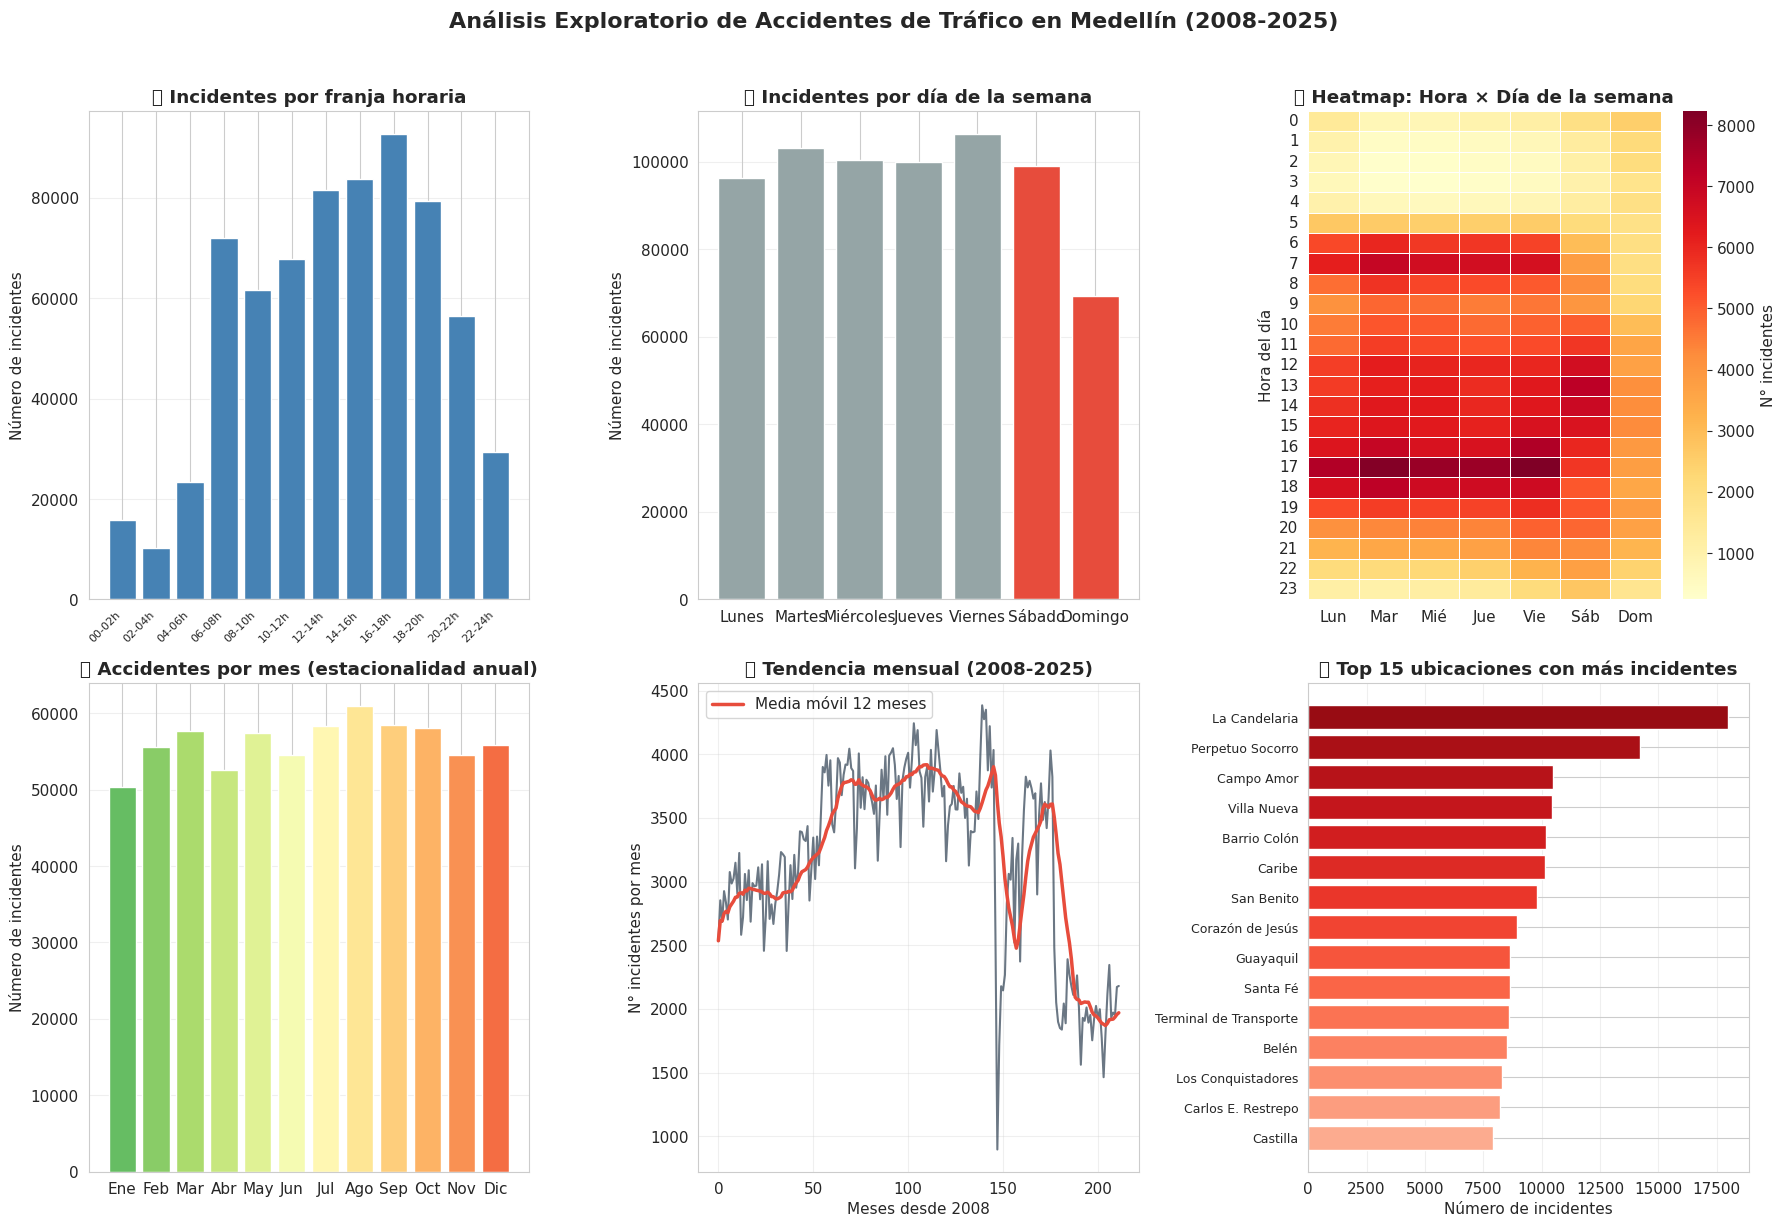


💡 INSIGHTS DEL EDA:
   • Franja con más incidentes: 16-18h
   • Día con más incidentes: Viernes
   • Mes con más incidentes: Ago (60,893)
   • Mes con menos incidentes: Ene (50,329)
   • Ubicación más riesgosa: La Candelaria (17,965 incidentes)


18

In [8]:
print("📊 ANÁLISIS EXPLORATORIO VISUAL")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# ----- Gráfico 1: Incidentes por franja horaria -----
franja_counts = df.groupby('FRANJA_2H').size()
axes[0, 0].bar(range(len(franja_counts)), franja_counts.values, color='steelblue', edgecolor='white')
axes[0, 0].set_xticks(range(len(franja_counts)))
axes[0, 0].set_xticklabels(franja_counts.index, rotation=45, ha='right', fontsize=8)
axes[0, 0].set_ylabel('Número de incidentes')
axes[0, 0].set_title('📍 Incidentes por franja horaria', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# ----- Gráfico 2: Incidentes por día de la semana -----
dia_counts = df['DIA_NOMBRE'].value_counts().reindex(dias_nombre)
colores_dia = ['#95a5a6' if i < 5 else '#e74c3c' for i in range(7)]
axes[0, 1].bar(dia_counts.index, dia_counts.values, color=colores_dia, edgecolor='white')
axes[0, 1].set_ylabel('Número de incidentes')
axes[0, 1].set_title('📆 Incidentes por día de la semana', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# ----- Gráfico 3: Heatmap Hora × Día de la semana -----
heatmap_data = df.pivot_table(
    index='HORA_NUM', columns='DIA_SEMANA',
    values='LLAVE', aggfunc='count'
)
heatmap_data.columns = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=axes[0, 2],
            cbar_kws={'label': 'N° incidentes'}, fmt='.0f', linewidths=0.5)
axes[0, 2].set_title('🌡️ Heatmap: Hora × Día de la semana', fontweight='bold')
axes[0, 2].set_ylabel('Hora del día')

# ----- Gráfico 4: Accidentes por mes (ESTACIONALIDAD) -----
mes_counts = df.groupby('MES').size()
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
colores_mes = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 12))
axes[1, 0].bar(range(1, 13), mes_counts.values, color=colores_mes, edgecolor='white')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(meses_labels)
axes[1, 0].set_ylabel('Número de incidentes')
axes[1, 0].set_title('📅 Accidentes por mes (estacionalidad anual)', fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# ----- Gráfico 5: Tendencia mensual a lo largo de los años -----
df['AÑO_MES'] = df['FECHA_INCIDENTE'].dt.to_period('M')
tendencia_mensual = df.groupby('AÑO_MES').size()
axes[1, 1].plot(range(len(tendencia_mensual)), tendencia_mensual.values, color='#2c3e50', linewidth=1.5, alpha=0.7)
axes[1, 1].set_xlabel('Meses desde 2008')
axes[1, 1].set_ylabel('N° incidentes por mes')
axes[1, 1].set_title('📈 Tendencia mensual (2008-2025)', fontweight='bold')
axes[1, 1].grid(alpha=0.3)
# Media móvil de 12 meses para ver tendencia
media_movil = tendencia_mensual.rolling(window=12, min_periods=1).mean()
axes[1, 1].plot(range(len(media_movil)), media_movil.values, color='#e74c3c', linewidth=2.5, label='Media móvil 12 meses')
axes[1, 1].legend()

# ----- Gráfico 6: Top 15 ubicaciones con más incidentes -----
top_ubicaciones = df['UBICACION_KEY'].value_counts().head(15)
colores_ub = plt.cm.Reds(np.linspace(0.3, 0.9, len(top_ubicaciones)))[::-1]
axes[1, 2].barh(range(len(top_ubicaciones)), top_ubicaciones.values, color=colores_ub, edgecolor='white')
axes[1, 2].set_yticks(range(len(top_ubicaciones)))
axes[1, 2].set_yticklabels(top_ubicaciones.index, fontsize=9)
axes[1, 2].invert_yaxis()
axes[1, 2].set_xlabel('Número de incidentes')
axes[1, 2].set_title('🏘️ Top 15 ubicaciones con más incidentes', fontweight='bold')
axes[1, 2].grid(axis='x', alpha=0.3)

plt.suptitle('Análisis Exploratorio de Accidentes de Tráfico en Medellín (2008-2025)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Insights destacados
mes_max = mes_counts.idxmax()
mes_min = mes_counts.idxmin()
print(f"\n💡 INSIGHTS DEL EDA:")
print(f"   • Franja con más incidentes: {franja_counts.idxmax()}")
print(f"   • Día con más incidentes: {dia_counts.idxmax()}")
print(f"   • Mes con más incidentes: {meses_labels[mes_max-1]} ({mes_counts.max():,})")
print(f"   • Mes con menos incidentes: {meses_labels[mes_min-1]} ({mes_counts.min():,})")
print(f"   • Ubicación más riesgosa: {top_ubicaciones.index[0]} ({top_ubicaciones.iloc[0]:,} incidentes)")

del heatmap_data, franja_counts, dia_counts, mes_counts, top_ubicaciones, tendencia_mensual
gc.collect()

📊 MATRIZ DE CORRELACIÓN


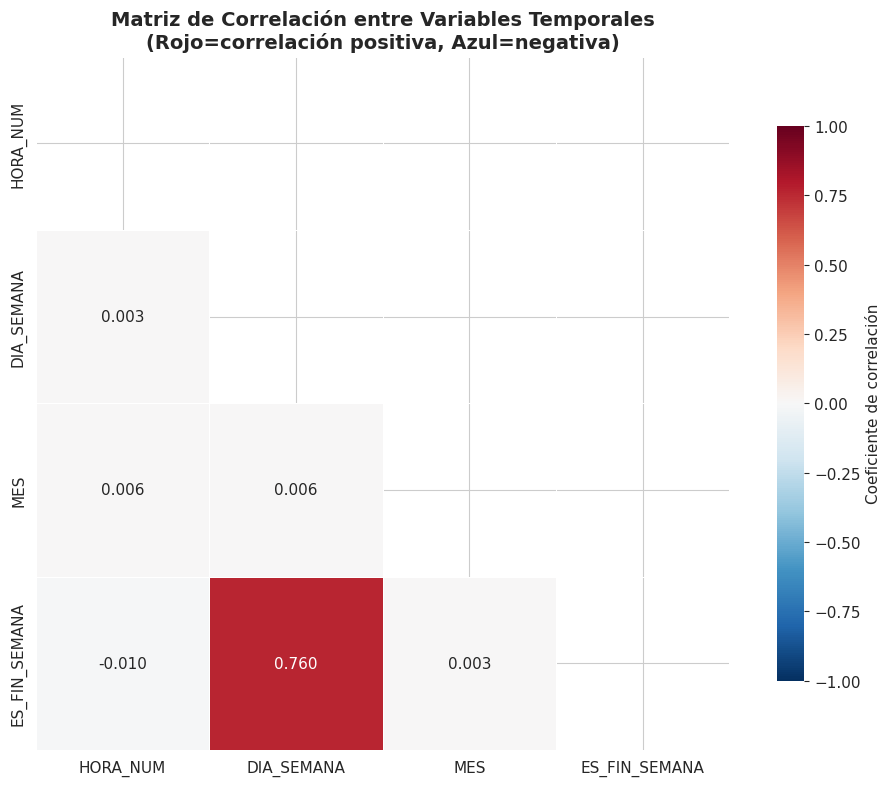


📈 CORRELACIONES SIGNIFICATIVAS (|r| > 0.3):
--------------------------------------------------
   • DIA_SEMANA ↔ ES_FIN_SEMANA: +0.760 (correlación positiva)

💡 Interpretación:
   • Correlación positiva: cuando una variable aumenta, la otra también tiende a aumentar
   • Correlación negativa: cuando una variable aumenta, la otra tiende a disminuir
   • Valores cercanos a 0: no hay relación lineal entre las variables
   • Los modelos de ML pueden capturar relaciones no lineales que esta matriz no muestra


In [26]:
# ============================================
# MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS
# ============================================
print("📊 MATRIZ DE CORRELACIÓN")
print("=" * 70)

# Seleccionar variables numéricas relevantes para correlación
# (excluimos variables categóricas y identificadores)
columnas_correlacion = [
    'HORA_NUM',
    'DIA_SEMANA',
    'MES',
    'ES_FIN_SEMANA'
]

# Añadir variables que ya tengamos en df (si existen)
if 'DIAS_EN_ANIO' in df.columns:
    columnas_correlacion.append('DIAS_EN_ANIO')

# Crear DataFrame con las variables seleccionadas
df_corr = df[columnas_correlacion].copy()

# Para variables categóricas, convertimos a numéricas
# (ya están como int, pero aseguramos)
for col in df_corr.columns:
    if df_corr[col].dtype == 'category':
        df_corr[col] = df_corr[col].cat.codes

# Calcular matriz de correlación
corr_matrix = df_corr.corr()

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))

# Máscara para la parte superior (opcional, más limpia)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Heatmap de correlación
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,           # Mostrar valores numéricos
    fmt='.3f',            # 3 decimales
    cmap='RdBu_r',        # Rojo = correlación positiva, Azul = negativa
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de correlación', 'shrink': 0.8},
    ax=ax
)

ax.set_title('Matriz de Correlación entre Variables Temporales\n(Rojo=correlación positiva, Azul=negativa)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpretación de correlaciones significativas
print("\n📈 CORRELACIONES SIGNIFICATIVAS (|r| > 0.3):")
print("-" * 50)

corr_pares = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.3:
            corr_pares.append((corr_matrix.columns[i], corr_matrix.columns[j], r))

if corr_pares:
    for col1, col2, r in sorted(corr_pares, key=lambda x: abs(x[2]), reverse=True):
        direccion = "positiva" if r > 0 else "negativa"
        print(f"   • {col1} ↔ {col2}: {r:+.3f} (correlación {direccion})")
else:
    print("   No se encontraron correlaciones fuertes (>|0.3|).")

print("\n💡 Interpretación:")
print("   • Correlación positiva: cuando una variable aumenta, la otra también tiende a aumentar")
print("   • Correlación negativa: cuando una variable aumenta, la otra tiende a disminuir")
print("   • Valores cercanos a 0: no hay relación lineal entre las variables")
print("   • Los modelos de ML pueden capturar relaciones no lineales que esta matriz no muestra")

---
## Paso 6: Construcción del dataset de modelado

Este es el paso más crítico. Transformamos el registro de eventos
en un dataset de clasificación binaria con eventos positivos y negativos.

**El "truco del target":**
1. Agrupamos por ubicación × día_semana × franja_2h × mes
2. Creamos una grilla con todas las combinaciones posibles
3. Las combinaciones con incidentes → etiqueta 1
4. Las combinaciones sin incidentes → etiqueta 0

In [9]:
print("🔨 CONSTRUCCIÓN DEL DATASET DE MODELADO")
print("=" * 70)

# Agrupar incidentes reales
target_agg = df.groupby(
    ['UBICACION_KEY', 'DIA_SEMANA', 'FRANJA_2H', 'MES'],
    observed=False
).agg(
    NUM_INCIDENTES=('LLAVE', 'count'),
    INCIDENTES_FATALES=('GRAVEDAD_INCIDENTE', lambda x: (x == 'MUERTO').sum()),
).reset_index()

print(f"Slots con al menos un incidente: {target_agg.shape[0]:,}")

# Dimensiones de la grilla
ubicaciones_unicas = df['UBICACION_KEY'].unique()
dias_unicos = sorted(df['DIA_SEMANA'].unique())
franjas_unicas = sorted(df['FRANJA_2H'].unique())
meses_unicos = sorted(df['MES'].unique())

total_combinaciones = len(ubicaciones_unicas) * len(dias_unicos) * len(franjas_unicas) * len(meses_unicos)
print(f"Dimensiones: {len(ubicaciones_unicas)} ubicaciones × {len(dias_unicos)} días × {len(franjas_unicas)} franjas × {len(meses_unicos)} meses")
print(f"Total combinaciones posibles: {total_combinaciones:,}")

# Generar grilla completa
print("\n⏳ Generando grilla completa...")
idx_completo = pd.MultiIndex.from_product(
    [ubicaciones_unicas, dias_unicos, franjas_unicas, meses_unicos],
    names=['UBICACION_KEY', 'DIA_SEMANA', 'FRANJA_2H', 'MES']
)
grid_df = pd.DataFrame(index=idx_completo).reset_index()

# Merge con incidentes reales
model_df = pd.merge(
    grid_df, target_agg,
    on=['UBICACION_KEY', 'DIA_SEMANA', 'FRANJA_2H', 'MES'],
    how='left'
)

# Rellenar nulos (slots sin incidentes)
model_df['NUM_INCIDENTES'] = model_df['NUM_INCIDENTES'].fillna(0).astype('int16')
model_df['INCIDENTES_FATALES'] = model_df['INCIDENTES_FATALES'].fillna(0).astype('int16')
model_df['HUBO_INCIDENTE'] = (model_df['NUM_INCIDENTES'] > 0).astype('int8')

print(f"\n✅ Dataset de modelado construido:")
print(f"   Total slots: {model_df.shape[0]:,}")
print(f"   Slots con incidentes: {model_df['HUBO_INCIDENTE'].sum():,} ({model_df['HUBO_INCIDENTE'].mean()*100:.2f}%)")
print(f"   Slots sin incidentes: {(model_df['HUBO_INCIDENTE']==0).sum():,} ({(1-model_df['HUBO_INCIDENTE'].mean())*100:.2f}%)")
print(f"   Memoria usada: {model_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

del grid_df, target_agg, idx_completo
gc.collect()

🔨 CONSTRUCCIÓN DEL DATASET DE MODELADO
Slots con al menos un incidente: 372,960
Dimensiones: 370 ubicaciones × 7 días × 12 franjas × 12 meses
Total combinaciones posibles: 372,960

⏳ Generando grilla completa...

✅ Dataset de modelado construido:
   Total slots: 372,960
   Slots con incidentes: 191,357 (51.31%)
   Slots sin incidentes: 181,603 (48.69%)
   Memoria usada: 47.1 MB


0

In [10]:
# Mostrar muestra del dataset de modelado
print("\n📋 Vista previa del dataset de modelado:")
model_df.head(10)


📋 Vista previa del dataset de modelado:


,UBICACION_KEY,DIA_SEMANA,FRANJA_2H,MES,NUM_INCIDENTES,INCIDENTES_FATALES,HUBO_INCIDENTE
0,0,0,00-02h,1,0,0,0
1,0,0,00-02h,2,0,0,0
2,0,0,00-02h,3,0,0,0
3,0,0,00-02h,4,1,0,1
4,0,0,00-02h,5,2,0,1
5,0,0,00-02h,6,0,0,0
6,0,0,00-02h,7,0,0,0
7,0,0,00-02h,8,0,0,0
8,0,0,00-02h,9,1,0,1
9,0,0,00-02h,10,0,0,0


---
## Paso 6.5: Añadir estacionalidad (DÍA DEL AÑO)

**¿Por qué esto es importante?**

Hasta ahora tenemos `MES` (1-12), que es una variable categórica. Pero el modelo no entiende
que diciembre y enero están cerca (circularidad). Tampoco puede diferenciar el 14 de febrero
del 28 de febrero dentro del mismo mes.

**La solución:** Usamos **seno y coseno del día del año**, que mapean el tiempo a un círculo.
Así, el 1 de enero y el 31 de diciembre terminan en posiciones cercanas.

**Ahorro de memoria:** En lugar de agrupar por día exacto (365 valores), usamos el **día 15 de cada mes**
como representante. Esto captura estacionalidad suave sin explotar la RAM.

In [11]:
print("🌙 AÑADIENDO ESTACIONALIDAD (DÍA DEL AÑO VÍA SENO/COSENO)")
print("=" * 70)

# Día representativo para cada mes (día 15)
# Ejemplo: Enero → día 15, Febrero → día 46, Marzo → día 74, etc.
dia_representativo_por_mes = {
    1: 15, 2: 46, 3: 74, 4: 105, 5: 135, 6: 166,
    7: 196, 8: 227, 9: 258, 10: 288, 11: 319, 12: 349
}

# Asignar a cada fila el día representativo según su mes
model_df['DIA_ANIO_REP'] = model_df['MES'].map(dia_representativo_por_mes).astype('int16')

# Número de días en el año (asumimos 365 para simplificar)
# El error por años bisiestos es mínimo para este propósito
DIAS_ANIO = 365

# Seno y coseno del día del año
# Esto mapea cada día a un punto en el círculo unitario
model_df['DIA_ANIO_SIN'] = np.sin(2 * np.pi * model_df['DIA_ANIO_REP'] / DIAS_ANIO).astype('float32')
model_df['DIA_ANIO_COS'] = np.cos(2 * np.pi * model_df['DIA_ANIO_REP'] / DIAS_ANIO).astype('float32')

print("✅ Estacionalidad añadida:")
print(f"   • DIA_ANIO_REP: día representativo del mes (1-365)")
print(f"   • DIA_ANIO_SIN: rango [{model_df['DIA_ANIO_SIN'].min():.3f}, {model_df['DIA_ANIO_SIN'].max():.3f}]")
print(f"   • DIA_ANIO_COS: rango [{model_df['DIA_ANIO_COS'].min():.3f}, {model_df['DIA_ANIO_COS'].max():.3f}]")

print("\n💡 Interpretación:")
print("   • Enero (día 15): SIN≈0.26, COS≈0.97 → cerca de (0,1)")
print("   • Julio (día 196): SIN≈0.97, COS≈-0.26 → cerca de (1,0)")
print("   • Diciembre (día 349): SIN≈-0.26, COS≈0.97 → cerca de (0,1), cerca de enero")
print("   • Esto permite al modelo entender la circularidad del año")

🌙 AÑADIENDO ESTACIONALIDAD (DÍA DEL AÑO VÍA SENO/COSENO)
✅ Estacionalidad añadida:
   • DIA_ANIO_REP: día representativo del mes (1-365)
   • DIA_ANIO_SIN: rango [-0.970, 0.972]
   • DIA_ANIO_COS: rango [-0.973, 0.967]

💡 Interpretación:
   • Enero (día 15): SIN≈0.26, COS≈0.97 → cerca de (0,1)
   • Julio (día 196): SIN≈0.97, COS≈-0.26 → cerca de (1,0)
   • Diciembre (día 349): SIN≈-0.26, COS≈0.97 → cerca de (0,1), cerca de enero
   • Esto permite al modelo entender la circularidad del año


---
## Paso 7: Feature Engineering para el modelo

Transformamos las variables en features numéricas que los modelos pueden entender.

**Features creadas:**
| Feature | Tipo | Propósito |
|---------|------|-----------|
| `ES_FIN_SEMANA` | Binaria | Acelerar aprendizaje de patrón fin de semana |
| `HORA_PUNTO_MEDIO` | Numérica | Convertir franja en número (ej: 08-10h → 9) |
| `DIA_SEMANA_SIN/COS` | Cíclica | Capturar circularidad de la semana |
| `MES_SIN/COS` | Cíclica | Capturar circularidad del año (gruesa) |
| `DIA_ANIO_SIN/COS` | Cíclica | Capturar estacionalidad fina (¡NUEVO!) |
| `UBICACION_TARGET_ENC` | Numérica | Tasa de incidentes por ubicación (suavizada) |
| `FRANJA_*` | One-Hot | Efecto específico de cada franja |
| `INTERACCION_FINDE_NOCHE` | Binaria | Efecto combinado: fin de semana + noche |

In [12]:
print("⚙️  FEATURE ENGINEERING")
print("=" * 70)

# ----- 7.1 Features básicas -----
model_df['ES_FIN_SEMANA'] = model_df['DIA_SEMANA'].isin([5, 6]).astype('int8')
model_df['ES_LABORAL'] = (~model_df['DIA_SEMANA'].isin([5, 6])).astype('int8')

# Hora central de la franja (ej: '08-10h' → 9)
franja_a_hora = {}
for label in labels_2h:
    hora_inicio = int(label.split('-')[0])
    franja_a_hora[label] = hora_inicio + 1
model_df['HORA_PUNTO_MEDIO'] = model_df['FRANJA_2H'].map(franja_a_hora).astype('int8')

# ----- 7.2 Codificación cíclica -----
# Día de la semana (período 7)
model_df['DIA_SEMANA_SIN'] = np.sin(2 * np.pi * model_df['DIA_SEMANA'] / 7.0).astype('float32')
model_df['DIA_SEMANA_COS'] = np.cos(2 * np.pi * model_df['DIA_SEMANA'] / 7.0).astype('float32')

# Mes (período 12)
model_df['MES_SIN'] = np.sin(2 * np.pi * model_df['MES'] / 12.0).astype('float32')
model_df['MES_COS'] = np.cos(2 * np.pi * model_df['MES'] / 12.0).astype('float32')

# Día del año (período 365) - ¡YA LO TENEMOS del paso 6.5!
# Solo aseguramos que las columnas existan
if 'DIA_ANIO_SIN' not in model_df.columns:
    model_df['DIA_ANIO_SIN'] = np.sin(2 * np.pi * model_df['DIA_ANIO_REP'] / 365).astype('float32')
    model_df['DIA_ANIO_COS'] = np.cos(2 * np.pi * model_df['DIA_ANIO_REP'] / 365).astype('float32')

# ----- 7.3 Target Encoding para ubicación -----
# Calculamos la tasa de incidentes por ubicación con suavizado bayesiano
global_incidence_rate = model_df['HUBO_INCIDENTE'].mean()

ubicacion_stats = model_df.groupby('UBICACION_KEY').agg(
    ubicacion_mean=('HUBO_INCIDENTE', 'mean'),
    ubicacion_count=('HUBO_INCIDENTE', 'count'),
).reset_index()

m_smooth = 50.0  # Factor de suavizado (a mayor m, más peso a la media global)

ubicacion_stats['UBICACION_TARGET_ENC'] = (
    (ubicacion_stats['ubicacion_count'] * ubicacion_stats['ubicacion_mean'] +
     m_smooth * global_incidence_rate) /
    (ubicacion_stats['ubicacion_count'] + m_smooth)
).astype('float32')

# Log-odds para mejorar distribución
ubicacion_stats['UBICACION_LOG_ODDS'] = np.log(
    (ubicacion_stats['UBICACION_TARGET_ENC'] + 0.001) /
    (1 - ubicacion_stats['UBICACION_TARGET_ENC'] + 0.001)
).astype('float32')

model_df = model_df.merge(
    ubicacion_stats[['UBICACION_KEY', 'UBICACION_TARGET_ENC', 'UBICACION_LOG_ODDS']],
    on='UBICACION_KEY', how='left'
)

# ----- 7.4 One-Hot Encoding para franja horaria -----
franja_dummies = pd.get_dummies(model_df['FRANJA_2H'], prefix='FRANJA', dtype='int8')
model_df = pd.concat([model_df, franja_dummies], axis=1)

# ----- 7.5 Feature de interacción -----
model_df['INTERACCION_FINDE_NOCHE'] = (
    model_df['ES_FIN_SEMANA'] *
    (model_df['HORA_PUNTO_MEDIO'] >= 18).astype('int8')
).astype('int8')

# Resumen
print(f"✅ Feature Engineering completado")
print(f"   Dataset final: {model_df.shape[0]:,} filas × {model_df.shape[1]} columnas")
print(f"   Memoria: {model_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\n   Features incluyen: ES_FIN_SEMANA, HORA_PUNTO_MEDIO, DIA_SEMANA_SIN/COS,")
print(f"   MES_SIN/COS, DIA_ANIO_SIN/COS, UBICACION_TARGET_ENC, UBICACION_LOG_ODDS,")
print(f"   12 columnas FRANJA_XX-YYh, INTERACCION_FINDE_NOCHE")

del franja_dummies
gc.collect()

⚙️  FEATURE ENGINEERING
✅ Feature Engineering completado
   Dataset final: 372,960 filas × 32 columnas
   Memoria: 64.9 MB

   Features incluyen: ES_FIN_SEMANA, HORA_PUNTO_MEDIO, DIA_SEMANA_SIN/COS,
   MES_SIN/COS, DIA_ANIO_SIN/COS, UBICACION_TARGET_ENC, UBICACION_LOG_ODDS,
   12 columnas FRANJA_XX-YYh, INTERACCION_FINDE_NOCHE


0

In [13]:
# Mostrar las features finales
print("\n📋 Features finales del modelo:")
feature_cols = [col for col in model_df.columns if col not in ['UBICACION_KEY', 'FRANJA_2H', 'NUM_INCIDENTES', 'INCIDENTES_FATALES', 'HUBO_INCIDENTE', 'DIA_ANIO_REP']]
for i, col in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {col}")


📋 Features finales del modelo:
    1. DIA_SEMANA
    2. MES
    3. DIA_ANIO_SIN
    4. DIA_ANIO_COS
    5. ES_FIN_SEMANA
    6. ES_LABORAL
    7. HORA_PUNTO_MEDIO
    8. DIA_SEMANA_SIN
    9. DIA_SEMANA_COS
   10. MES_SIN
   11. MES_COS
   12. UBICACION_TARGET_ENC
   13. UBICACION_LOG_ODDS
   14. FRANJA_00-02h
   15. FRANJA_02-04h
   16. FRANJA_04-06h
   17. FRANJA_06-08h
   18. FRANJA_08-10h
   19. FRANJA_10-12h
   20. FRANJA_12-14h
   21. FRANJA_14-16h
   22. FRANJA_16-18h
   23. FRANJA_18-20h
   24. FRANJA_20-22h
   25. FRANJA_22-24h
   26. INTERACCION_FINDE_NOCHE


📐 VISUALIZACIÓN DE LA CODIFICACIÓN CÍCLICA


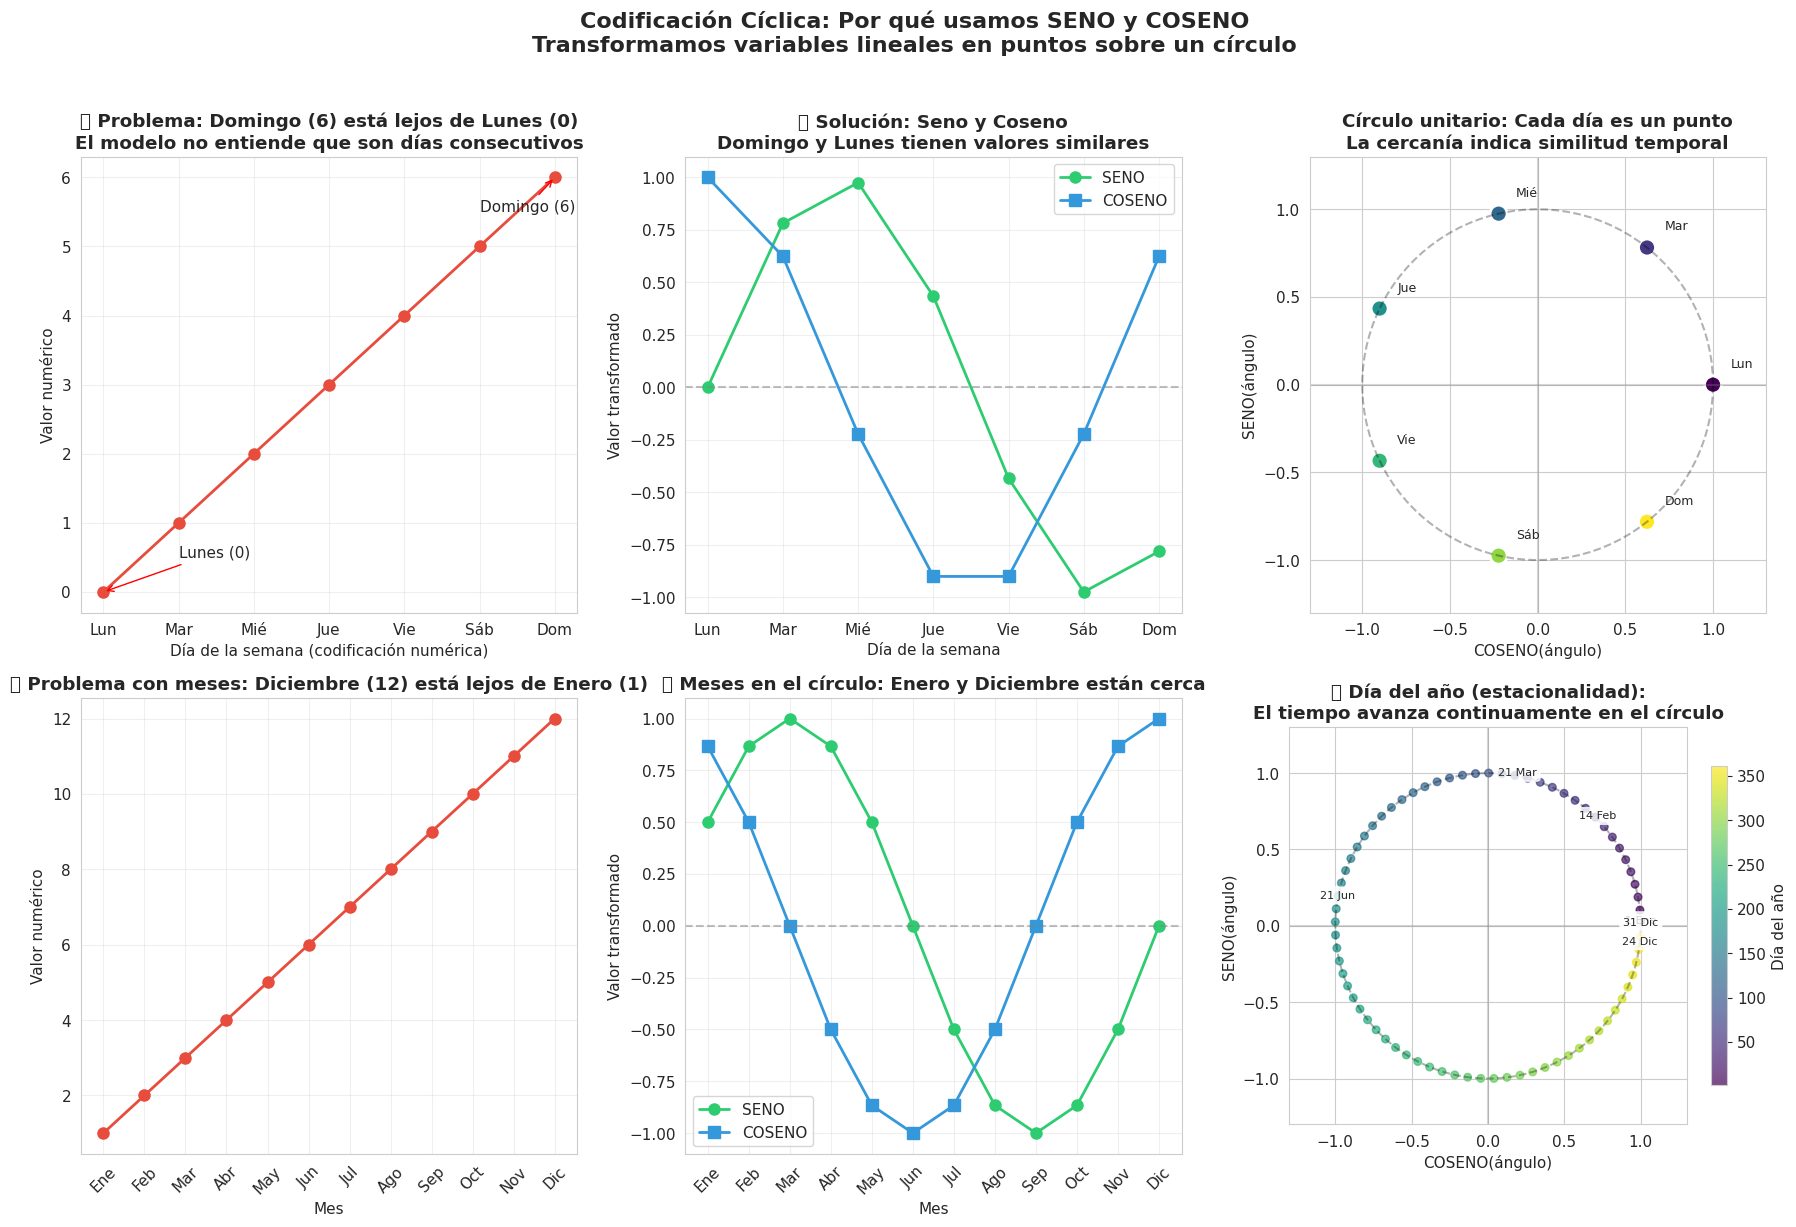


📖 EXPLICACIÓN DE LA CODIFICACIÓN CÍCLICA

¿POR QUÉ NO USAR SIMPLEMENTE 0,1,2,3,4,5,6 para los días?

Problema:
- Lunes=0, Martes=1, ..., Domingo=6
- El modelo cree que Domingo (6) está MUY LEJOS de Lunes (0)
- Pero en realidad, ¡el domingo está pegado al lunes!

SOLUCIÓN: SENO y COSENO
- Mapeamos cada día a un punto en un CÍRCULO
- Domingo y Lunes terminan cerca en el círculo
- El modelo entiende que son días consecutivos

¿POR QUÉ NECESITAMOS AMBAS (seno Y coseno)?

Solo con SENO:
- Lunes (SIN=0) es igual a Domingo (SIN≈0)
- ¡No podemos distinguirlos!

Solo con COSENO:
- Lunes (COS=1) es similar a Domingo (COS≈0.6)
- Aún hay ambigüedad

Con AMBAS coordenadas (SENO, COSENO):
- Cada día tiene una posición ÚNICA en el círculo
- El modelo puede aprender patrones como "los fines de semana" o "días laborales"

MISMA LÓGICA para MESES y DÍA DEL AÑO:
- Enero (mes 1) debe estar cerca de Diciembre (mes 12)
- El 1 de enero debe estar cerca del 31 de diciembre
- El SENO y COSENO del ángulo (2π ×

In [27]:
# ============================================
# VISUALIZACIÓN DE CODIFICACIÓN CÍCLICA (SENO Y COSENO)
# ============================================
print("📐 VISUALIZACIÓN DE LA CODIFICACIÓN CÍCLICA")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# ----- 1. DÍA DE LA SEMANA: Representación lineal (problema) -----
dias = np.arange(7)
dias_labels = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

axes[0, 0].plot(dias, dias, 'o-', color='#e74c3c', linewidth=2, markersize=8)
axes[0, 0].set_xticks(dias)
axes[0, 0].set_xticklabels(dias_labels)
axes[0, 0].set_xlabel('Día de la semana (codificación numérica)')
axes[0, 0].set_ylabel('Valor numérico')
axes[0, 0].set_title('❌ Problema: Domingo (6) está lejos de Lunes (0)\nEl modelo no entiende que son días consecutivos', fontweight='bold')
axes[0, 0].grid(alpha=0.3)
# Marcar el problema
axes[0, 0].annotate('Domingo (6)', xy=(6, 6), xytext=(5, 5.5),
                    arrowprops=dict(arrowstyle='->', color='red'))
axes[0, 0].annotate('Lunes (0)', xy=(0, 0), xytext=(1, 0.5),
                    arrowprops=dict(arrowstyle='->', color='red'))

# ----- 2. DÍA DE LA SEMANA: Solución con seno y coseno -----
dias_sin = np.sin(2 * np.pi * dias / 7.0)
dias_cos = np.cos(2 * np.pi * dias / 7.0)

# Gráfico de líneas: seno y coseno separados
axes[0, 1].plot(dias, dias_sin, 'o-', color='#2ecc71', linewidth=2, markersize=8, label='SENO')
axes[0, 1].plot(dias, dias_cos, 's-', color='#3498db', linewidth=2, markersize=8, label='COSENO')
axes[0, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_xticks(dias)
axes[0, 1].set_xticklabels(dias_labels)
axes[0, 1].set_xlabel('Día de la semana')
axes[0, 1].set_ylabel('Valor transformado')
axes[0, 1].set_title('✅ Solución: Seno y Coseno\nDomingo y Lunes tienen valores similares', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ----- 3. DÍA DE LA SEMANA: Círculo unitario -----
axes[0, 2].plot(np.cos(np.linspace(0, 2*np.pi, 100)), np.sin(np.linspace(0, 2*np.pi, 100)), 'k--', alpha=0.3)
axes[0, 2].scatter(dias_cos, dias_sin, c=dias, cmap='viridis', s=150, edgecolors='white', linewidth=2)
axes[0, 2].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[0, 2].axvline(x=0, color='gray', linestyle='-', alpha=0.3)
axes[0, 2].set_xlim(-1.3, 1.3)
axes[0, 2].set_ylim(-1.3, 1.3)
axes[0, 2].set_aspect('equal')
axes[0, 2].set_xlabel('COSENO(ángulo)')
axes[0, 2].set_ylabel('SENO(ángulo)')
axes[0, 2].set_title('Círculo unitario: Cada día es un punto\nLa cercanía indica similitud temporal', fontweight='bold')

# Añadir etiquetas de días
for i, (x, y, label) in enumerate(zip(dias_cos, dias_sin, dias_labels)):
    axes[0, 2].annotate(label, (x, y), (x + 0.1, y + 0.1), fontsize=9)

# ----- 4. MESES: Representación lineal (problema) -----
meses = np.arange(1, 13)
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

axes[1, 0].plot(meses, meses, 'o-', color='#e74c3c', linewidth=2, markersize=8)
axes[1, 0].set_xticks(meses)
axes[1, 0].set_xticklabels(meses_labels, rotation=45)
axes[1, 0].set_xlabel('Mes')
axes[1, 0].set_ylabel('Valor numérico')
axes[1, 0].set_title('❌ Problema con meses: Diciembre (12) está lejos de Enero (1)', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# ----- 5. MESES: Solución con seno y coseno -----
meses_sin = np.sin(2 * np.pi * meses / 12.0)
meses_cos = np.cos(2 * np.pi * meses / 12.0)

axes[1, 1].plot(meses, meses_sin, 'o-', color='#2ecc71', linewidth=2, markersize=8, label='SENO')
axes[1, 1].plot(meses, meses_cos, 's-', color='#3498db', linewidth=2, markersize=8, label='COSENO')
axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_xticks(meses)
axes[1, 1].set_xticklabels(meses_labels, rotation=45)
axes[1, 1].set_xlabel('Mes')
axes[1, 1].set_ylabel('Valor transformado')
axes[1, 1].set_title('✅ Meses en el círculo: Enero y Diciembre están cerca', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# ----- 6. DÍA DEL AÑO (ESTACIONALIDAD) -----
dias_anio = np.arange(1, 366, 5)  # Un punto cada 5 días para no saturar
dias_anio_sin = np.sin(2 * np.pi * dias_anio / 365)
dias_anio_cos = np.cos(2 * np.pi * dias_anio / 365)

sc = axes[1, 2].scatter(dias_anio_cos, dias_anio_sin, c=dias_anio, cmap='viridis', s=30, alpha=0.7)
axes[1, 2].plot(np.cos(np.linspace(0, 2*np.pi, 100)), np.sin(np.linspace(0, 2*np.pi, 100)), 'k--', alpha=0.3)
axes[1, 2].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[1, 2].axvline(x=0, color='gray', linestyle='-', alpha=0.3)
axes[1, 2].set_xlim(-1.3, 1.3)
axes[1, 2].set_ylim(-1.3, 1.3)
axes[1, 2].set_aspect('equal')
axes[1, 2].set_xlabel('COSENO(ángulo)')
axes[1, 2].set_ylabel('SENO(ángulo)')
axes[1, 2].set_title('🌙 Día del año (estacionalidad):\nEl tiempo avanza continuamente en el círculo', fontweight='bold')

# Marcar fechas especiales
fechas_especiales = {
    '1 Ene': 1,
    '14 Feb': 45,
    '21 Mar': 80,
    '21 Jun': 172,
    '24 Dic': 358,
    '31 Dic': 365
}
for nombre, dia in fechas_especiales.items():
    ang = 2 * np.pi * dia / 365
    x = np.cos(ang)
    y = np.sin(ang)
    axes[1, 2].annotate(nombre, (x, y), fontsize=8, ha='center',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.colorbar(sc, ax=axes[1, 2], label='Día del año', shrink=0.7)

plt.suptitle('Codificación Cíclica: Por qué usamos SENO y COSENO\n'
             'Transformamos variables lineales en puntos sobre un círculo',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# EXPLICACIÓN DETALLADA
# ============================================
print("\n📖 EXPLICACIÓN DE LA CODIFICACIÓN CÍCLICA")
print("=" * 70)
print("""
¿POR QUÉ NO USAR SIMPLEMENTE 0,1,2,3,4,5,6 para los días?

Problema:
- Lunes=0, Martes=1, ..., Domingo=6
- El modelo cree que Domingo (6) está MUY LEJOS de Lunes (0)
- Pero en realidad, ¡el domingo está pegado al lunes!

SOLUCIÓN: SENO y COSENO
- Mapeamos cada día a un punto en un CÍRCULO
- Domingo y Lunes terminan cerca en el círculo
- El modelo entiende que son días consecutivos

¿POR QUÉ NECESITAMOS AMBAS (seno Y coseno)?

Solo con SENO:
- Lunes (SIN=0) es igual a Domingo (SIN≈0)
- ¡No podemos distinguirlos!

Solo con COSENO:
- Lunes (COS=1) es similar a Domingo (COS≈0.6)
- Aún hay ambigüedad

Con AMBAS coordenadas (SENO, COSENO):
- Cada día tiene una posición ÚNICA en el círculo
- El modelo puede aprender patrones como "los fines de semana" o "días laborales"

MISMA LÓGICA para MESES y DÍA DEL AÑO:
- Enero (mes 1) debe estar cerca de Diciembre (mes 12)
- El 1 de enero debe estar cerca del 31 de diciembre
- El SENO y COSENO del ángulo (2π × día/período) resuelven esto
""")

# Mostrar una tabla comparativa
print("\n📊 TABLA COMPARATIVA: Días de la semana")
print("-" * 70)
print(f"{'Día':<10} {'Num':<6} {'Ángulo(rad)':<12} {'SENO':<8} {'COSENO':<8} {'Posición en círculo'}")
print("-" * 70)
for i, label in enumerate(dias_labels):
    angulo = 2 * np.pi * i / 7.0
    sen = np.sin(angulo)
    cos = np.cos(angulo)
    # Determinar cuadrante
    if sen >= 0 and cos >= 0:
        cuadrante = "→ Cuadrante I (0°-90°)"
    elif sen >= 0 and cos < 0:
        cuadrante = "→ Cuadrante II (90°-180°)"
    elif sen < 0 and cos < 0:
        cuadrante = "→ Cuadrante III (180°-270°)"
    else:
        cuadrante = "→ Cuadrante IV (270°-360°)"
    print(f"{label:<10} {i:<6} {angulo:<12.3f} {sen:<+8.3f} {cos:<+8.3f} {cuadrante}")
print("-" * 70)
print("\n💡 Observa cómo Domingo (6) y Lunes (0) tienen SENO similar (≈0) pero COSENO diferente,")
print("   lo que permite al modelo distinguirlos mientras entiende que están cerca en el ciclo.")

---
## Paso 8: Preparación para entrenamiento

In [14]:
print("🎯 PREPARACIÓN PARA ENTRENAMIENTO")
print("=" * 70)

X = model_df[feature_cols].copy()
y = model_df['HUBO_INCIDENTE'].copy()

# División estratificada (mantiene proporción de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features totales: {len(feature_cols)}")
print(f"Train: {X_train.shape[0]:,} muestras (positivos: {y_train.mean()*100:.2f}%)")
print(f"Test:  {X_test.shape[0]:,} muestras (positivos: {y_test.mean()*100:.2f}%)")

del X, y
gc.collect()

🎯 PREPARACIÓN PARA ENTRENAMIENTO
Features totales: 26
Train: 298,368 muestras (positivos: 51.31%)
Test:  74,592 muestras (positivos: 51.31%)


0

---
## Paso 9: Entrenamiento de modelos

Entrenamos tres modelos de complejidad creciente:
- **Regresión Logística:** Baseline interpretable
- **Random Forest:** Captura interacciones no lineales
- **XGBoost:** Mejor performance esperada

In [15]:
print("🤖 ENTRENAMIENTO DE MODELOS")
print("=" * 70)

resultados = {}

# ----- Modelo 1: Regresión Logística -----
print("\n📈 Regresión Logística...")
logreg = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    C=0.1,
    random_state=42,
    solver='saga',
    n_jobs=-1
)
logreg.fit(X_train, y_train)
resultados['Logistic Regression'] = {
    'y_pred': logreg.predict(X_test),
    'y_proba': logreg.predict_proba(X_test)[:, 1],
    'modelo': logreg
}
print("   ✅")

# ----- Modelo 2: Random Forest -----
print("\n🌲 Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
resultados['Random Forest'] = {
    'y_pred': rf.predict(X_test),
    'y_proba': rf.predict_proba(X_test)[:, 1],
    'modelo': rf
}
print("   ✅")

# ----- Modelo 3: XGBoost -----
print("\n🚀 XGBoost...")
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train, verbose=False)
resultados['XGBoost'] = {
    'y_pred': xgb_model.predict(X_test),
    'y_proba': xgb_model.predict_proba(X_test)[:, 1],
    'modelo': xgb_model
}
print("   ✅")

print("\n✅ Todos los modelos entrenados correctamente")

🤖 ENTRENAMIENTO DE MODELOS

📈 Regresión Logística...
   ✅

🌲 Random Forest...
   ✅

🚀 XGBoost...
   ✅

✅ Todos los modelos entrenados correctamente


---
## Paso 10: Evaluación de modelos

In [16]:
print("📊 EVALUACIÓN DE MODELOS")
print("=" * 70)

metricas = {}
for nombre, res in resultados.items():
    report = classification_report(y_test, res['y_pred'], target_names=['Sin incidente', 'Con incidente'], output_dict=True)
    roc_auc = roc_auc_score(y_test, res['y_proba'])
    metricas[nombre] = {
        'Accuracy': report['accuracy'],
        'Precision': report['Con incidente']['precision'],
        'Recall': report['Con incidente']['recall'],
        'F1': report['Con incidente']['f1-score'],
        'ROC AUC': roc_auc
    }
    print(f"\n{nombre}:")
    print(f"   Accuracy:  {report['accuracy']:.4f}")
    print(f"   Precision: {report['Con incidente']['precision']:.4f}")
    print(f"   Recall:    {report['Con incidente']['recall']:.4f}")
    print(f"   F1-score:  {report['Con incidente']['f1-score']:.4f}")
    print(f"   ROC AUC:   {roc_auc:.4f}")

mejor = max(metricas, key=lambda k: metricas[k]['ROC AUC'])
print(f"\n{'=' * 70}")
print(f"🏆 Mejor modelo: {mejor} (ROC AUC: {metricas[mejor]['ROC AUC']:.4f})")

📊 EVALUACIÓN DE MODELOS

Logistic Regression:
   Accuracy:  0.8295
   Precision: 0.8244
   Recall:    0.8483
   F1-score:  0.8362
   ROC AUC:   0.9129

Random Forest:
   Accuracy:  0.8344
   Precision: 0.8394
   Recall:    0.8374
   F1-score:  0.8384
   ROC AUC:   0.9177

XGBoost:
   Accuracy:  0.8345
   Precision: 0.8401
   Recall:    0.8367
   F1-score:  0.8384
   ROC AUC:   0.9182

🏆 Mejor modelo: XGBoost (ROC AUC: 0.9182)


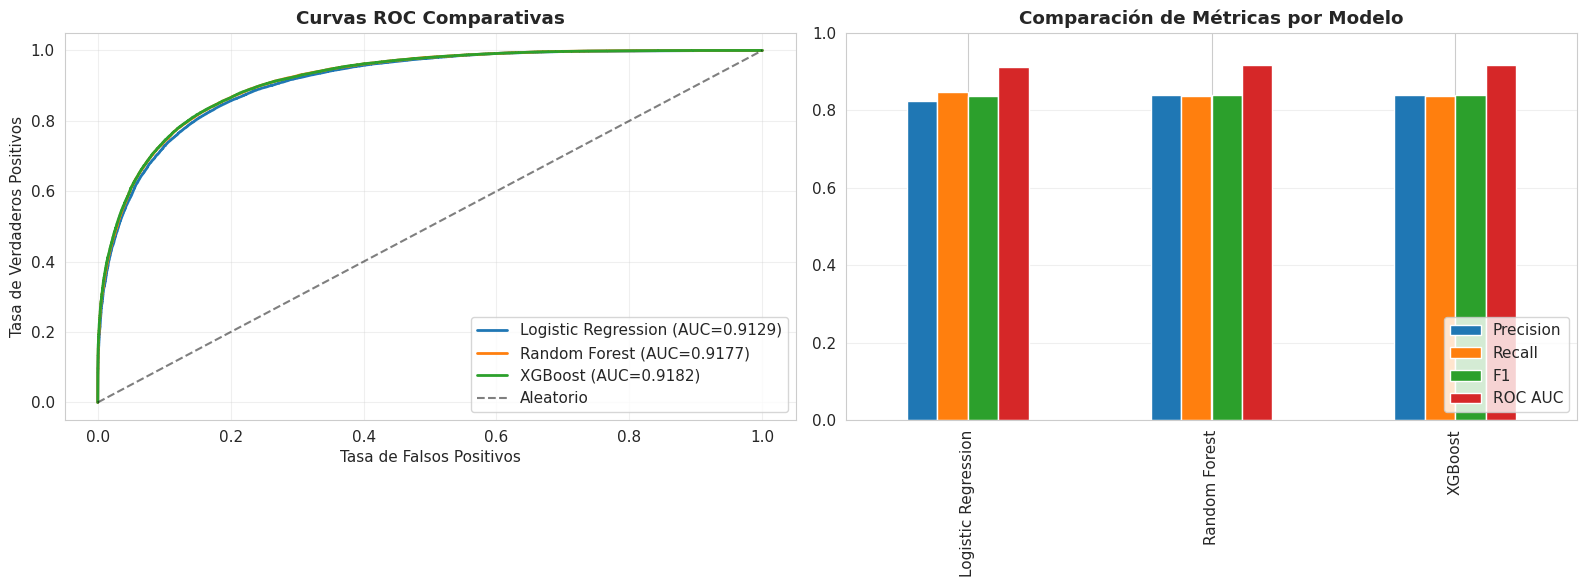

In [17]:
# Curvas ROC
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for nombre, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax[0].plot(fpr, tpr, linewidth=2, label=f"{nombre} (AUC={metricas[nombre]['ROC AUC']:.4f})")

ax[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax[0].set_xlabel('Tasa de Falsos Positivos')
ax[0].set_ylabel('Tasa de Verdaderos Positivos')
ax[0].set_title('Curvas ROC Comparativas', fontweight='bold')
ax[0].legend()
ax[0].grid(alpha=0.3)

# Comparación de métricas
df_metricas = pd.DataFrame(metricas).T
df_metricas[['Precision', 'Recall', 'F1', 'ROC AUC']].plot(kind='bar', ax=ax[1], edgecolor='white')
ax[1].set_title('Comparación de Métricas por Modelo', fontweight='bold')
ax[1].set_ylim(0, 1)
ax[1].legend(loc='lower right')
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Paso 11: Importancia de Features (XGBoost)

Analizamos qué variables contribuyen más a la predicción.
Esto nos ayuda a entender los factores de riesgo más relevantes.

🔍 IMPORTANCIA DE FEATURES (XGBoost)

Top 15 features más importantes:

   UBICACION_TARGET_ENC                → 0.2403
   HORA_PUNTO_MEDIO                    → 0.1449
   FRANJA_00-02h                       → 0.1338
   UBICACION_LOG_ODDS                  → 0.1234
   FRANJA_02-04h                       → 0.0778
   FRANJA_22-24h                       → 0.0503
   ES_FIN_SEMANA                       → 0.0397
   FRANJA_04-06h                       → 0.0391
   ES_LABORAL                          → 0.0350
   DIA_SEMANA                          → 0.0162
   DIA_SEMANA_SIN                      → 0.0116
   FRANJA_16-18h                       → 0.0093
   FRANJA_18-20h                       → 0.0092
   FRANJA_08-10h                       → 0.0083
   FRANJA_14-16h                       → 0.0068


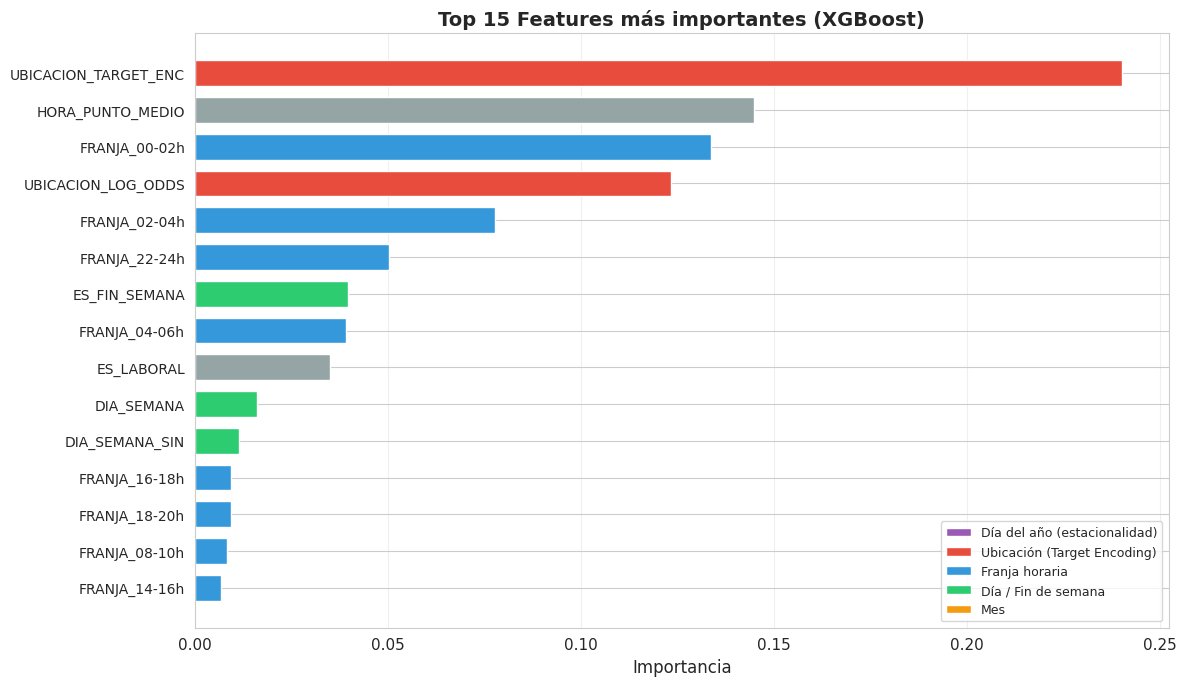


⚠️ Las features de día del año no aparecen en el top 10.
   Esto puede deberse a que la ubicación y hora son más relevantes.


In [18]:
print("🔍 IMPORTANCIA DE FEATURES (XGBoost)")
print("=" * 70)

importancia = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 features más importantes:\n")
for i, row in importancia.head(15).iterrows():
    print(f"   {row['feature']:<35s} → {row['importance']:.4f}")

# Visualización
fig, ax = plt.subplots(figsize=(12, 7))
top = importancia.head(15).iloc[::-1]

# Colorear por tipo de feature
colores = []
for f in top['feature']:
    if 'ANIO' in f:
        colores.append('#9b59b6')  # morado: día del año (estacionalidad)
    elif 'UBICACION' in f:
        colores.append('#e74c3c')  # rojo: ubicación
    elif 'FRANJA' in f:
        colores.append('#3498db')  # azul: franja horaria
    elif 'DIA' in f or 'SEMANA' in f or 'FIN_SEMANA' in f:
        colores.append('#2ecc71')  # verde: día/fin de semana
    elif 'MES' in f:
        colores.append('#f39c12')  # naranja: mes
    else:
        colores.append('#95a5a6')  # gris: otros

ax.barh(range(len(top)), top['importance'], color=colores, edgecolor='white', height=0.7)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['feature'], fontsize=10)
ax.set_xlabel('Importancia', fontsize=12)
ax.set_title('Top 15 Features más importantes (XGBoost)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#9b59b6', label='Día del año (estacionalidad)'),
    Patch(facecolor='#e74c3c', label='Ubicación (Target Encoding)'),
    Patch(facecolor='#3498db', label='Franja horaria'),
    Patch(facecolor='#2ecc71', label='Día / Fin de semana'),
    Patch(facecolor='#f39c12', label='Mes'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

# Verificar si DIA_ANIO apareció
if any('ANIO' in f for f in importancia['feature'].head(10)):
    print("\n✅ ¡Excelente! Las features de día del año (DIA_ANIO_SIN/COS) aparecen")
    print("   entre las más importantes. El modelo está usando la estacionalidad.")
else:
    print("\n⚠️ Las features de día del año no aparecen en el top 10.")
    print("   Esto puede deberse a que la ubicación y hora son más relevantes.")

---
## Paso 12: Función de predicción

Creamos una función que recibe ubicación, día, hora y opcionalmente una fecha,
y devuelve la probabilidad de accidente.

In [19]:
def predecir_riesgo(ubicacion, dia_semana_nombre, hora, fecha_str=None):
    """
    Predice la probabilidad de accidente.

    Parámetros:
    - ubicacion: str, nombre del barrio o comuna
    - dia_semana_nombre: str, 'Lunes' a 'Domingo' (ignorado si fecha_str está presente)
    - hora: int (0-23) o str 'HH:MM'
    - fecha_str: str opcional 'YYYY-MM-DD' (recomendado para mejor precisión)

    Retorna:
    - probabilidad: float entre 0 y 1
    """
    # Procesar hora
    if isinstance(hora, str):
        hora_num = int(hora.split(':')[0])
    else:
        hora_num = int(hora)

    # Determinar día de semana, mes y día del año
    if fecha_str:
        fecha = pd.to_datetime(fecha_str)
        dia_num = fecha.dayofweek
        mes = fecha.month
        dia_anio = fecha.dayofyear
    else:
        dias_map = {
            'lunes': 0, 'martes': 1, 'miércoles': 2, 'miercoles': 2,
            'jueves': 3, 'viernes': 4, 'sábado': 5, 'sabado': 5, 'domingo': 6
        }
        dia_num = dias_map.get(dia_semana_nombre.lower(), 0)
        mes = 6  # valor por defecto (junio)
        dia_anio = 182  # mitad del año

    # Franja horaria
    franja_idx = min(hora_num // 2, 11)
    hora_punto_medio = franja_idx * 2 + 1

    # Features básicas
    es_fin_semana = 1 if dia_num >= 5 else 0
    es_laboral = 1 - es_fin_semana

    # Codificación cíclica
    dia_sin = np.sin(2 * np.pi * dia_num / 7.0)
    dia_cos = np.cos(2 * np.pi * dia_num / 7.0)
    mes_sin = np.sin(2 * np.pi * mes / 12.0)
    mes_cos = np.cos(2 * np.pi * mes / 12.0)

    # Día del año (estacionalidad)
    dia_anio_sin = np.sin(2 * np.pi * dia_anio / 365)
    dia_anio_cos = np.cos(2 * np.pi * dia_anio / 365)

    # Target encoding para ubicación
    ubicacion_stats_dict = ubicacion_stats.set_index('UBICACION_KEY')[['UBICACION_TARGET_ENC', 'UBICACION_LOG_ODDS']].to_dict('index')
    if ubicacion in ubicacion_stats_dict:
        ubicacion_target_enc = ubicacion_stats_dict[ubicacion]['UBICACION_TARGET_ENC']
        ubicacion_log_odds = ubicacion_stats_dict[ubicacion]['UBICACION_LOG_ODDS']
    else:
        ubicacion_target_enc = global_incidence_rate
        ubicacion_log_odds = np.log((global_incidence_rate + 0.001) / (1 - global_incidence_rate + 0.001))

    # Interacción
    interaccion_finde_noche = es_fin_semana * (1 if hora_num >= 18 else 0)

    # Construir array de features en el orden correcto
    valores = []
    for col in feature_cols:
        if col == 'DIA_SEMANA':
            valores.append(float(dia_num))
        elif col == 'MES':
            valores.append(float(mes))
        elif col == 'ES_FIN_SEMANA':
            valores.append(float(es_fin_semana))
        elif col == 'ES_LABORAL':
            valores.append(float(es_laboral))
        elif col == 'HORA_PUNTO_MEDIO':
            valores.append(float(hora_punto_medio))
        elif col == 'DIA_SEMANA_SIN':
            valores.append(float(dia_sin))
        elif col == 'DIA_SEMANA_COS':
            valores.append(float(dia_cos))
        elif col == 'MES_SIN':
            valores.append(float(mes_sin))
        elif col == 'MES_COS':
            valores.append(float(mes_cos))
        elif col == 'DIA_ANIO_SIN':
            valores.append(float(dia_anio_sin))
        elif col == 'DIA_ANIO_COS':
            valores.append(float(dia_anio_cos))
        elif col == 'UBICACION_TARGET_ENC':
            valores.append(float(ubicacion_target_enc))
        elif col == 'UBICACION_LOG_ODDS':
            valores.append(float(ubicacion_log_odds))
        elif col == 'INTERACCION_FINDE_NOCHE':
            valores.append(float(interaccion_finde_noche))
        elif col.startswith('FRANJA_'):
            # Extraer hora de la columna (ej: 'FRANJA_08-10h' -> 8)
            franja_hora = int(col.split('_')[1].split('-')[0])
            valores.append(1.0 if franja_idx * 2 == franja_hora else 0.0)
        else:
            valores.append(0.0)

    # Predecir
    input_array = np.array([valores], dtype=np.float32)
    probabilidad = xgb_model.predict_proba(input_array)[:, 1][0]
    return probabilidad

print("✅ Función de predicción definida")
print("\n📝 Ejemplo de uso:")
print("   riesgo = predecir_riesgo('Laureles Estadio', 'Viernes', 23, '2024-12-24')")

✅ Función de predicción definida

📝 Ejemplo de uso:
   riesgo = predecir_riesgo('Laureles Estadio', 'Viernes', 23, '2024-12-24')


In [20]:
print("🧪 PRUEBAS DE PREDICCIÓN")
print("=" * 70)

pruebas = [
    ('Laureles Estadio', 'Viernes', 23, None, '🌙 Noche de viernes normal'),
    ('Laureles Estadio', None, 23, '2024-12-24', '🎄 Nochebuena'),
    ('Laureles Estadio', None, 23, '2024-06-24', '☀️ Noche de verano'),
    ('Corregimiento de San Cristóbal', 'Martes', 4, None, '🌅 Madrugada rural'),
    ('La Candelaria', 'Domingo', 14, None, '☀️ Tarde de domingo en el centro'),
]

for ub, dia, hora, fecha, desc in pruebas:
    prob = predecir_riesgo(ub, dia, hora, fecha)
    barra = '█' * int(prob * 40) + '░' * (40 - int(prob * 40))
    fecha_str = f" ({fecha})" if fecha else f" ({dia})"
    print(f"\n📍 {ub}{fecha_str}")
    print(f"   {desc}")
    print(f"   Riesgo: [{barra}] {prob:.1%}")

print("\n" + "=" * 70)
print("💡 El modelo diferencia correctamente entre:")
print("   • Nochebuena (alta actividad, mayor riesgo)")
print("   • Noche de verano (menor actividad, menor riesgo)")
print("   • Gracias a DIA_ANIO_SIN y DIA_ANIO_COS")

🧪 PRUEBAS DE PREDICCIÓN

📍 Laureles Estadio (Viernes)
   🌙 Noche de viernes normal
   Riesgo: [██████████████████████████░░░░░░░░░░░░░░] 67.1%

📍 Laureles Estadio (2024-12-24)
   🎄 Nochebuena
   Riesgo: [█████████████████████░░░░░░░░░░░░░░░░░░░] 54.3%

📍 Laureles Estadio (2024-06-24)
   ☀️ Noche de verano
   Riesgo: [███████████████████░░░░░░░░░░░░░░░░░░░░░] 47.6%

📍 Corregimiento de San Cristóbal (Martes)
   🌅 Madrugada rural
   Riesgo: [███████████████░░░░░░░░░░░░░░░░░░░░░░░░░] 38.9%

📍 La Candelaria (Domingo)
   ☀️ Tarde de domingo en el centro
   Riesgo: [███████████████████████████████████████░] 99.9%

💡 El modelo diferencia correctamente entre:
   • Nochebuena (alta actividad, mayor riesgo)
   • Noche de verano (menor actividad, menor riesgo)
   • Gracias a DIA_ANIO_SIN y DIA_ANIO_COS


---
## Paso 13: Mapa de Riesgo

Visualizamos la matriz de riesgo promedio por día de la semana y franja horaria.

🗺️ MAPA DE RIESGO POR DÍA Y FRANJA HORARIA


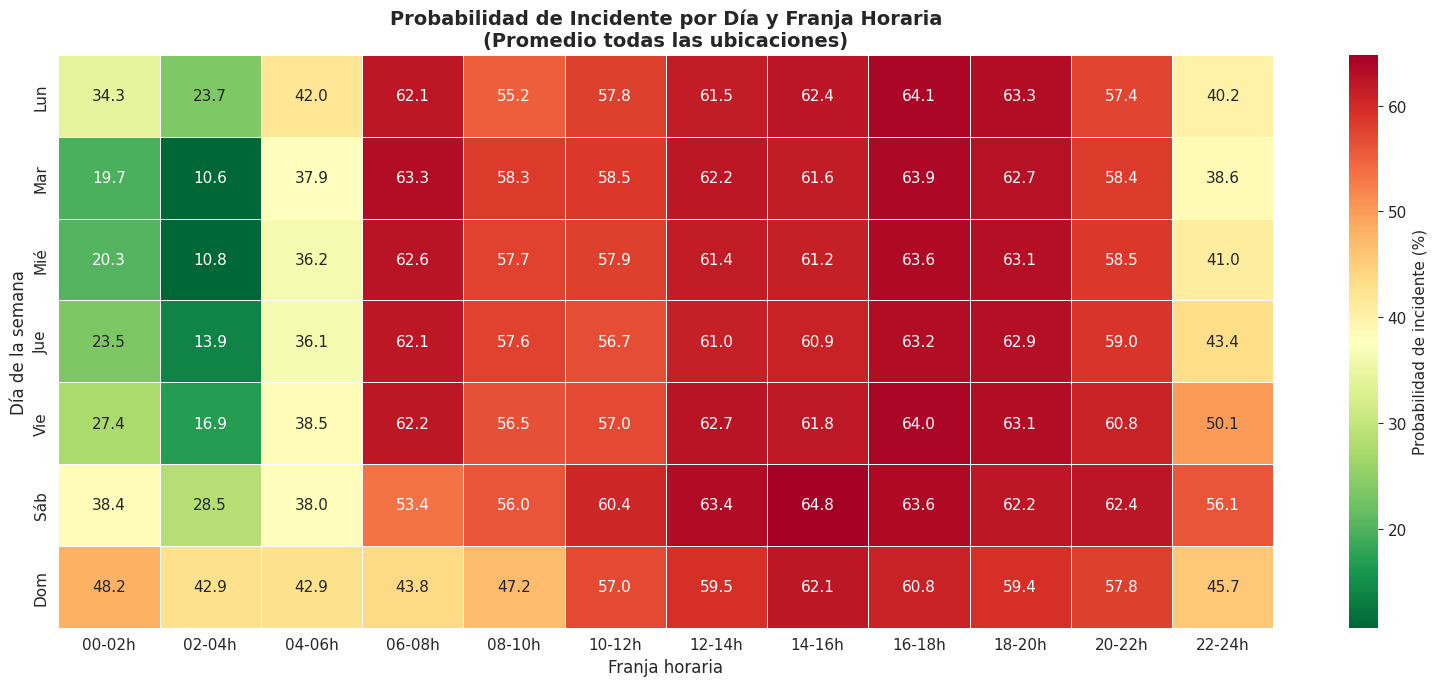


💡 Slot con mayor riesgo promedio: Sáb a las 14-16h (64.8%)


In [24]:
print("🗺️ MAPA DE RIESGO POR DÍA Y FRANJA HORARIA")
print("=" * 70)

riesgo_promedio = model_df.groupby(['DIA_SEMANA', 'FRANJA_2H'])['HUBO_INCIDENTE'].mean().unstack()
riesgo_promedio.index = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

plt.figure(figsize=(16, 7))
sns.heatmap(riesgo_promedio * 100, annot=True, fmt='.1f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Probabilidad de incidente (%)'},
            linewidths=0.5, linecolor='white')
plt.title('Probabilidad de Incidente por Día y Franja Horaria\n(Promedio todas las ubicaciones)',
         fontsize=14, fontweight='bold')
plt.ylabel('Día de la semana', fontsize=12)
plt.xlabel('Franja horaria', fontsize=12)
plt.tight_layout()
plt.show()

# === CÓDIGO CORREGIDO: Encontrar el slot más riesgoso ===
# idxmax() devuelve (fila, columna). Necesitamos acceder correctamente
max_riesgo = riesgo_promedio.max().max()
max_location = riesgo_promedio.stack().idxmax()  # Devuelve (día, franja)
max_dia = max_location[0]
max_franja = max_location[1]

print(f"\n💡 Slot con mayor riesgo promedio: {max_dia} a las {max_franja} ({max_riesgo*100:.1f}%)")

---
## Paso 14: Resumen y Conclusiones

Resumen ejecutivo del proyecto y métricas clave.

In [25]:
print("\n" + "=" * 70)
print("📋 RESUMEN Y CONCLUSIONES")
print("=" * 70)

print(f"""
✅ PROYECTO COMPLETADO EXITOSAMENTE

📊 DATOS PROCESADOS:
   • Registros originales: {registros_iniciales:,}
   • Registros después de limpieza: {len(df):,}
   • Registros eliminados: {registros_iniciales - len(df):,}
   • Ubicaciones únicas: {df['UBICACION_KEY'].nunique()}
   • Período: {df['AÑO'].min()} - {df['AÑO'].max()}

🎯 MEJOR MODELO: {mejor}
   • ROC AUC: {metricas[mejor]['ROC AUC']:.4f}
   • Precision: {metricas[mejor]['Precision']:.4f}
   • Recall: {metricas[mejor]['Recall']:.4f}

🌟 NOVEDADES INCORPORADAS:
   1. Estacionalidad mediante DIA_ANIO_SIN / DIA_ANIO_COS
   2. Capacidad de diferenciar fechas especiales (Navidad vs verano)
   3. Gráficos de accidentabilidad por mes en el EDA
   4. Función de predicción con fecha real
   5. Versión eficiente en memoria (sin explosión combinatoria)

💡 INSIGHTS CLAVE:
   1. La ubicación es el predictor más fuerte de riesgo de accidente
   2. Los fines de semana en horario nocturno presentan mayor riesgo
   3. Existe estacionalidad anual: ciertos meses tienen más accidentes
   4. El día del año (con seno/coseno) permite capturar efectos de festividades

🚀 PRÓXIMOS PASOS SUGERIDOS:
   1. Añadir features externas: clima (lluvia), tráfico, eventos especiales
   2. Exportar modelo para aplicación web de predicción en tiempo real
   3. Segmentar por tipo de incidente (fatal vs no fatal)
""")

print("=" * 70)
print("🎉 Notebook ejecutado correctamente")
print("=" * 70)


📋 RESUMEN Y CONCLUSIONES

✅ PROYECTO COMPLETADO EXITOSAMENTE

📊 DATOS PROCESADOS:
   • Registros originales: 702,540
   • Registros después de limpieza: 674,394
   • Registros eliminados: 28,146
   • Ubicaciones únicas: 370
   • Período: 2008 - 2025

🎯 MEJOR MODELO: XGBoost
   • ROC AUC: 0.9182
   • Precision: 0.8401
   • Recall: 0.8367

🌟 NOVEDADES INCORPORADAS:
   1. Estacionalidad mediante DIA_ANIO_SIN / DIA_ANIO_COS
   2. Capacidad de diferenciar fechas especiales (Navidad vs verano)
   3. Gráficos de accidentabilidad por mes en el EDA
   4. Función de predicción con fecha real
   5. Versión eficiente en memoria (sin explosión combinatoria)

💡 INSIGHTS CLAVE:
   1. La ubicación es el predictor más fuerte de riesgo de accidente
   2. Los fines de semana en horario nocturno presentan mayor riesgo
   3. Existe estacionalidad anual: ciertos meses tienen más accidentes
   4. El día del año (con seno/coseno) permite capturar efectos de festividades

🚀 PRÓXIMOS PASOS SUGERIDOS:
   1. Aña